In [2]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

This notebook will take snapshots and look at how the weights are disributed.

In [24]:
# List the directories for snapshots
init_type = "true_kaiming_normal"
model = "RhoLoss"
initial_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/initial_model.pth.tar"))
progress_start_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/progress_0.05.pth.tar"))
best_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/model_best.pth.tar"))

# Loads the snapshots

initial_snapshot = {}
progress_start_snapshot = {}
best_snapshot = {}
for path in initial_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in initial_snapshot:
            initial_snapshot[key] = []
        initial_snapshot[key].append(snapshot['state_dict'][key])

for key in initial_snapshot.keys():
    initial_snapshot[key] = torch.stack(initial_snapshot[key], dim=0)

for path in progress_start_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in progress_start_snapshot:
            progress_start_snapshot[key] = []
        progress_start_snapshot[key].append(snapshot['state_dict'][key])

for key in progress_start_snapshot.keys():
    progress_start_snapshot[key] = torch.stack(progress_start_snapshot[key], dim=0)

for path in best_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in best_snapshot:
            best_snapshot[key] = []
        best_snapshot[key].append(snapshot['state_dict'][key])

for key in best_snapshot.keys():
    best_snapshot[key] = torch.stack(best_snapshot[key], dim=0)


In [ ]:
lenet_keys = ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']

for snapshot in [initial_snapshot, progress_start_snapshot, best_snapshot]:
    for key in lenet_keys:
        data_shape = snapshot['state_dict'][key].shape
        data = snapshot['state_dict'][key].numpy().flatten()

        plt.clf()
        histo = plt.hist(data, bins=50, density=True, alpha=0.5, label='Snapshot Weights')
        plt.title(f"Histogram of {key} weights")
        plt.show()
        mean = np.mean(data)
        variance = np.var(data)

        print(data_shape)
        print(f"Mean: {mean}, Variance: {variance}")

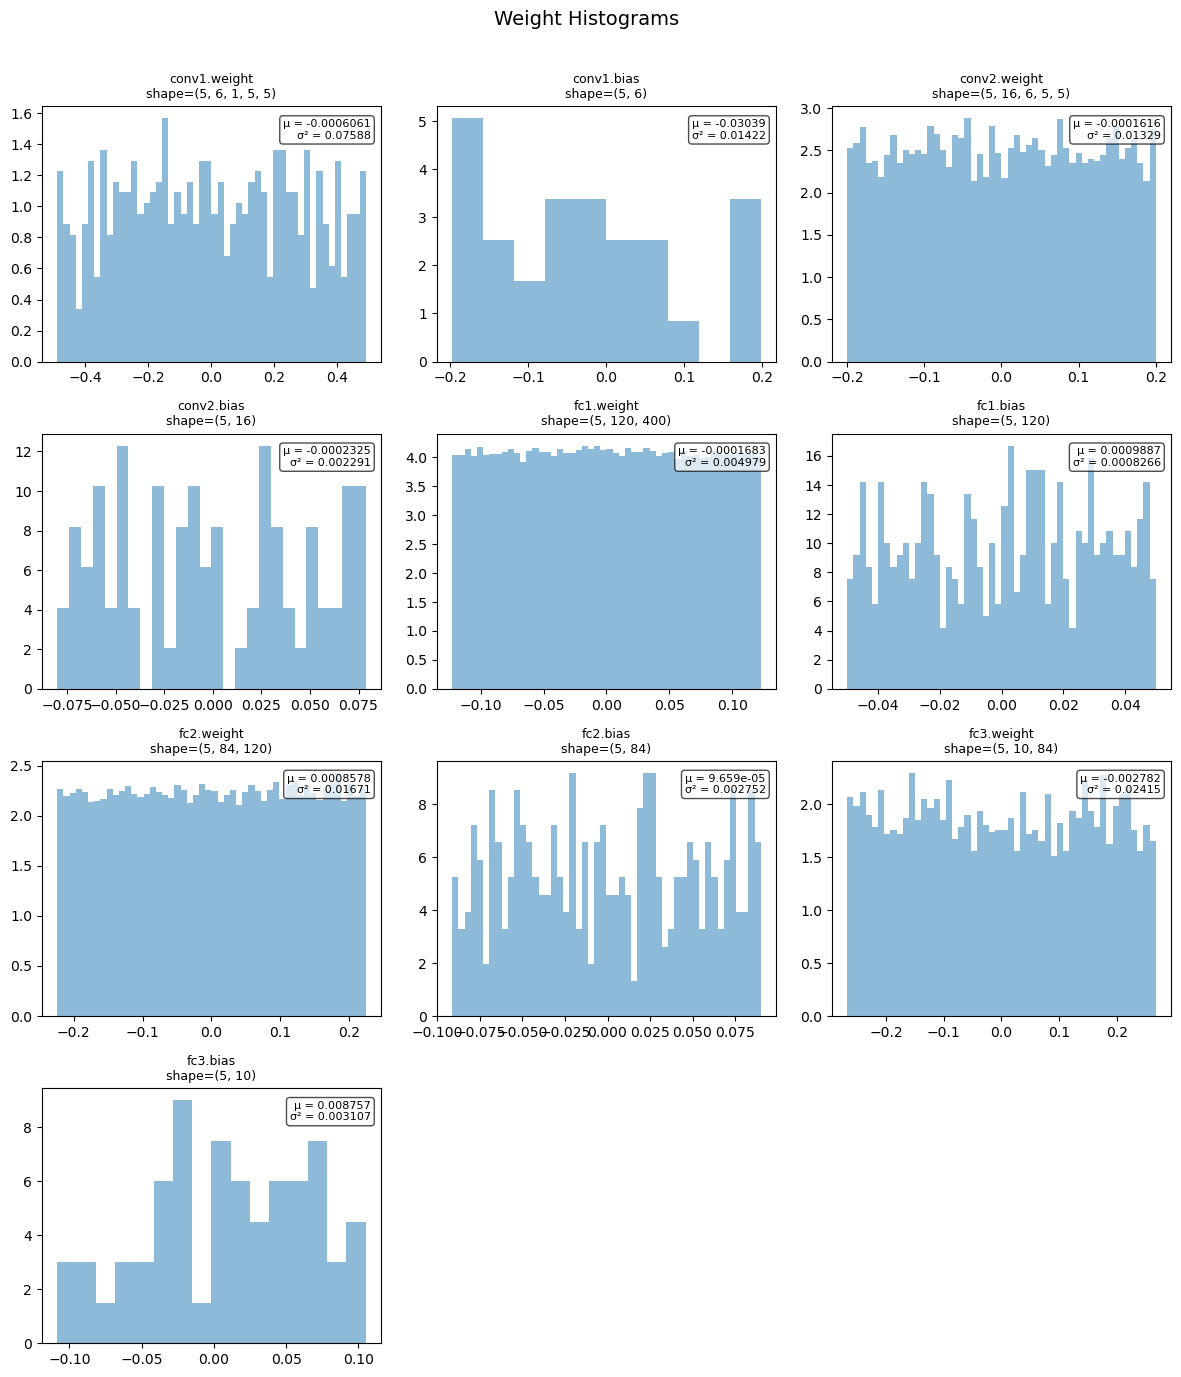

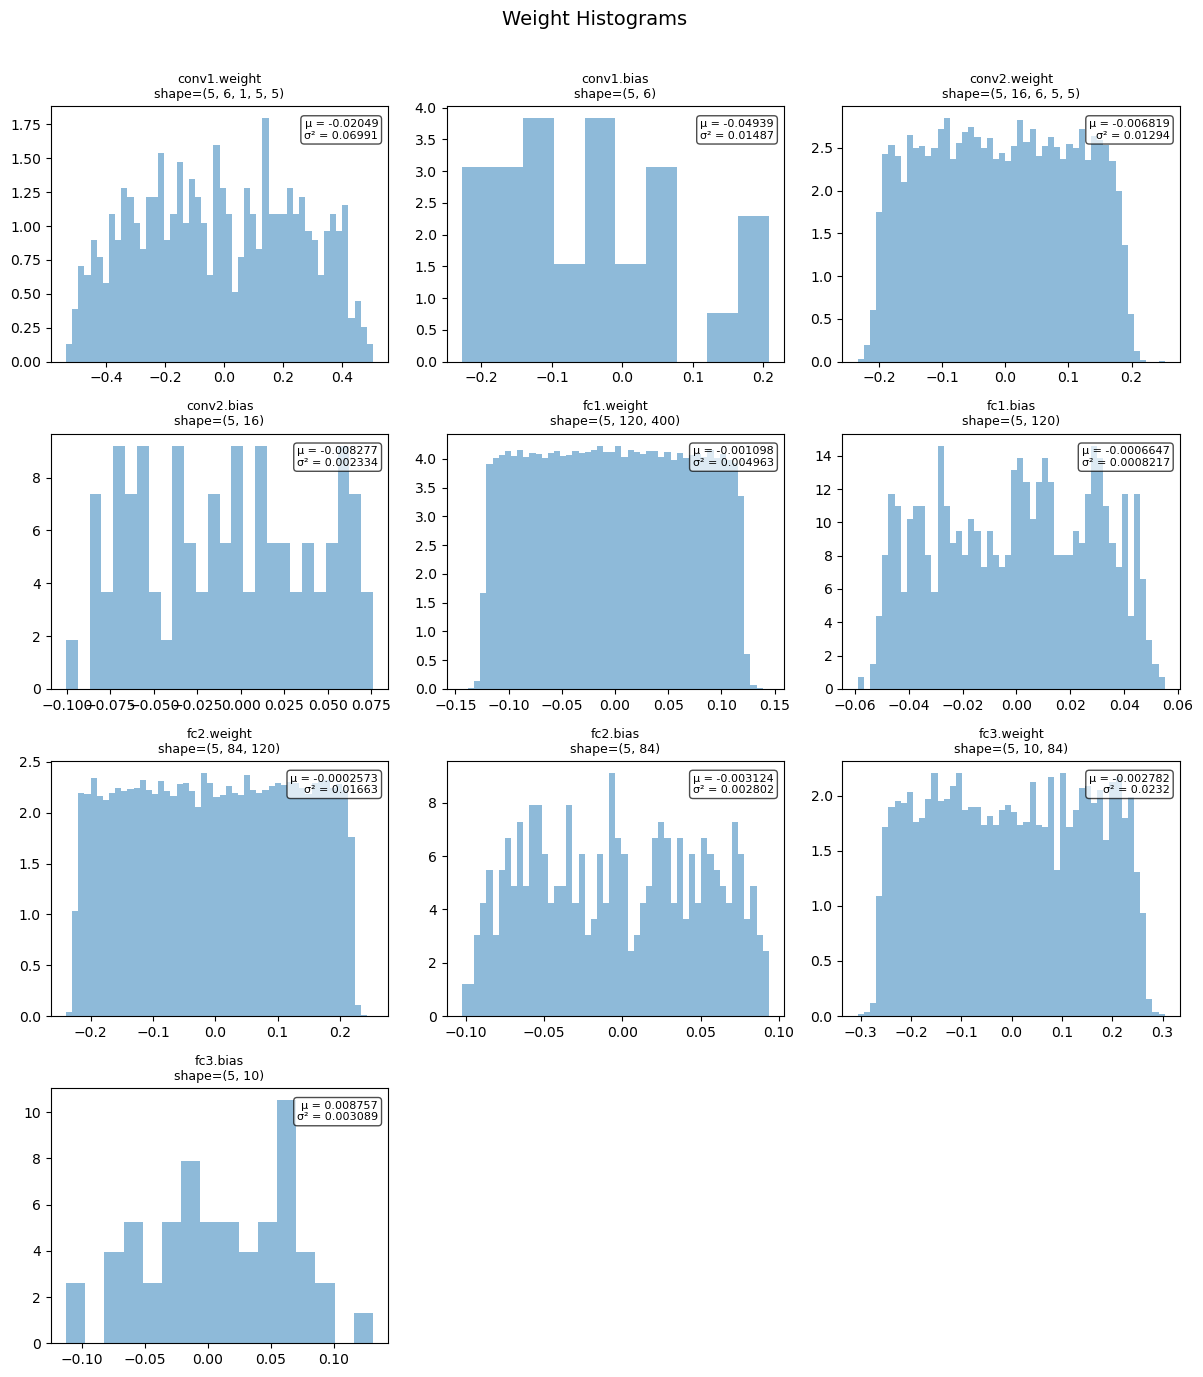

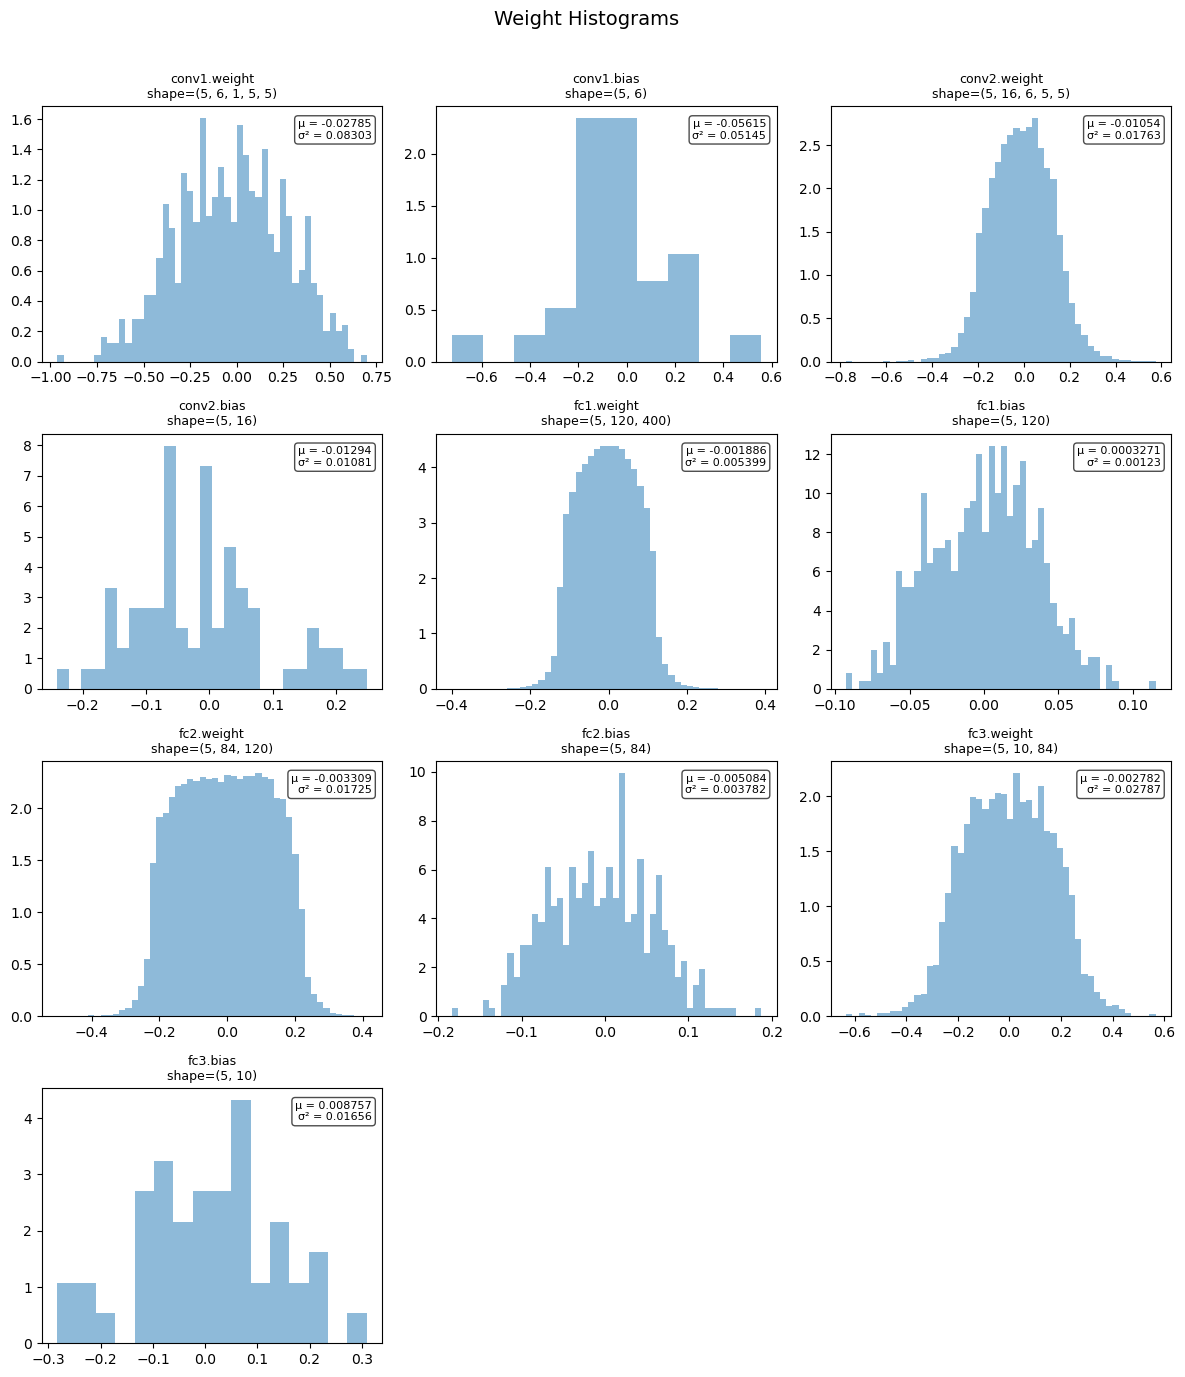

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

lenet_keys = ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias',
              'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias',
              'fc3.weight', 'fc3.bias']

for snapshot in [initial_snapshot, progress_start_snapshot, best_snapshot]:

    nrows, ncols = 4, 3

    # --- Figure 1: histograms ---
    fig1, axes1 = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    axes1 = axes1.reshape(-1)

    # --- Figure 2: fitted normal distributions ---
    # fig2, axes2 = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    # axes2 = axes2.reshape(-1)

    for i, key in enumerate(lenet_keys):
        data_shape = snapshot[key].shape
        data = snapshot[key].numpy().flatten()

        mean = np.mean(data)
        variance = np.var(data)
        std = np.sqrt(variance)

        # --- histogram subplot ---
        ax1 = axes1[i]
        bins = min(50, max(10, len(data) // 3))
        ax1.hist(data, bins=bins, density=True, alpha=0.5, label='Snapshot Weights')
        ax1.set_title(f"{key}\nshape={tuple(data_shape)}", fontsize=9)

        stats_str = f"μ = {mean:.4g}\nσ² = {variance:.4g}"
        ax1.text(0.97, 0.95, stats_str, transform=ax1.transAxes,
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        # # --- fitted normal distribution subplot ---
        # ax2 = axes2[i]
        # x = np.linspace(mean - 4*std, mean + 4*std, 300)
        # pdf = norm.pdf(x, loc=mean, scale=std)

        # ax2.plot(x, pdf, color='crimson', lw=2, label='Fitted Normal')
        # ax2.fill_between(x, pdf, alpha=0.2, color='crimson')
        # ax2.set_title(f"{key} (Normal fit)", fontsize=9)

        # ax2.text(0.97, 0.95, stats_str, transform=ax2.transAxes,
        #         ha='right', va='top', fontsize=8,
        #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # hide unused subplots (10 keys in 12 slots)
    for j in range(len(lenet_keys), nrows*ncols):
        axes1[j].axis('off')
        axes2[j].axis('off')

    fig1.suptitle("Weight Histograms", fontsize=14)
    fig1.tight_layout(rect=[0, 0, 1, 0.97])

    # fig2.suptitle("Fitted Normal Distributions", fontsize=14)
    # fig2.tight_layout(rect=[0, 0, 1, 0.97])

    plt.show()

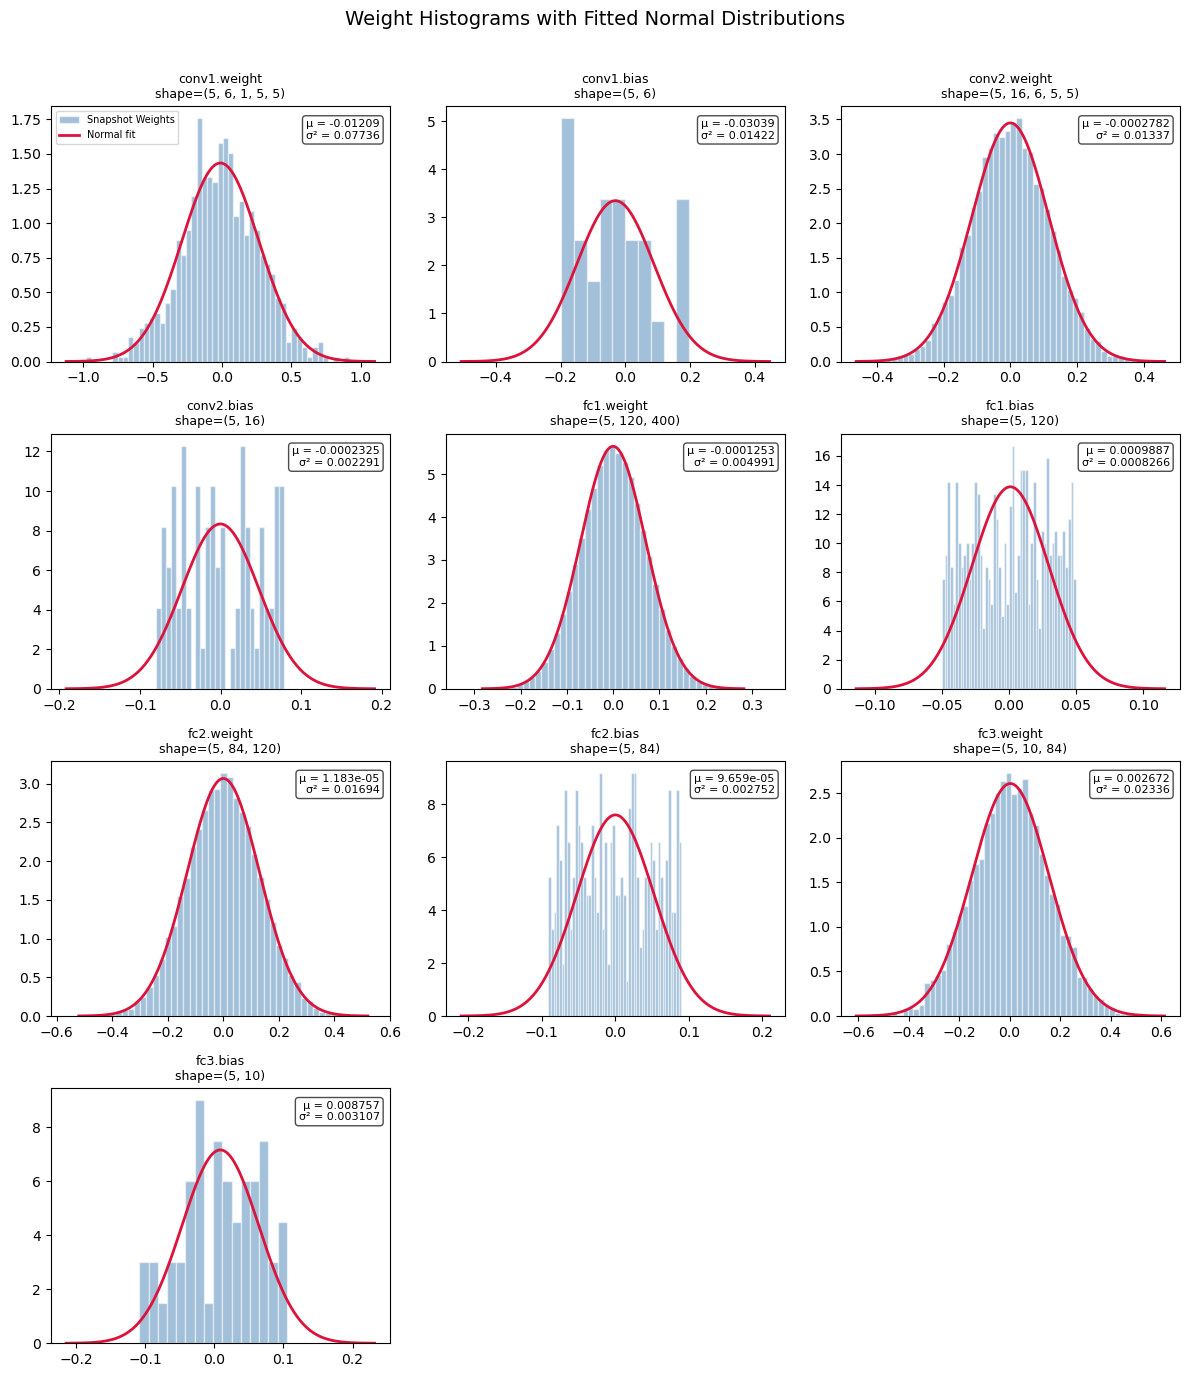

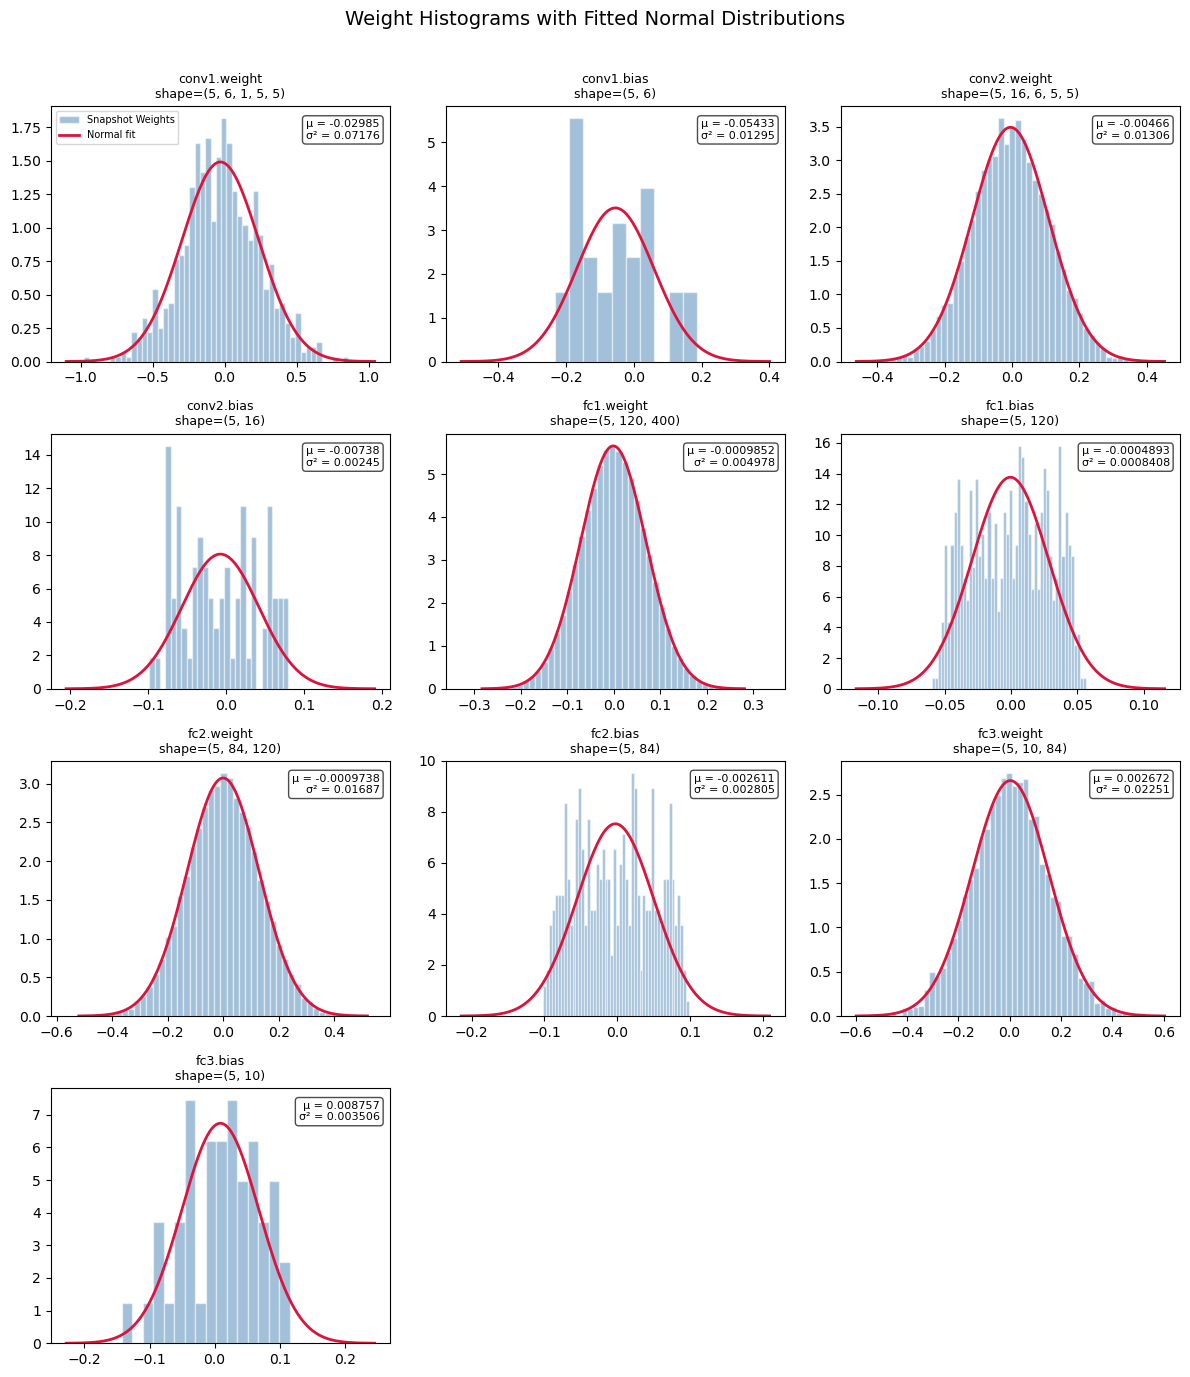

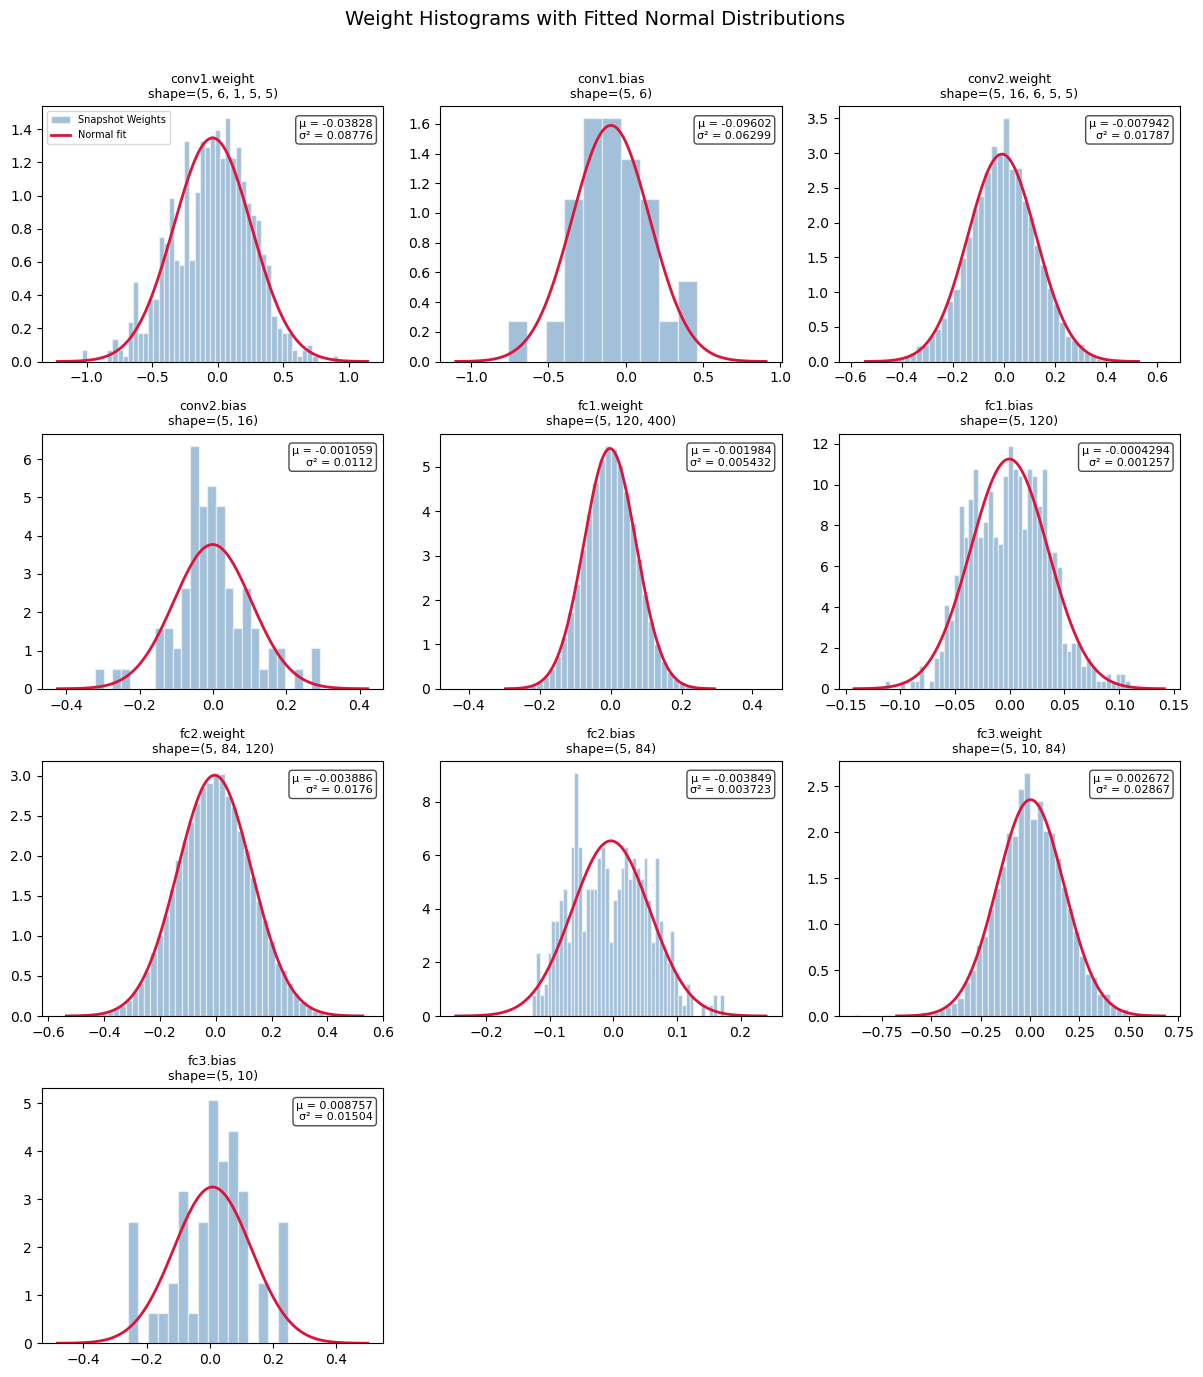

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

lenet_keys = ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias',
              'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias',
              'fc3.weight', 'fc3.bias']

for snapshot in [initial_snapshot, progress_start_snapshot, best_snapshot]:

    nrows, ncols = 4, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    axes = axes.reshape(-1)

    for i, key in enumerate(lenet_keys):
        ax = axes[i]

        data_shape = snapshot[key].shape
        data = snapshot[key].numpy().flatten()

        mean = np.mean(data)
        variance = np.var(data)
        std = np.sqrt(variance)

        # histogram (density=True so it's on the same scale as the pdf)
        bins = min(50, max(10, len(data) // 3))
        ax.hist(data, bins=bins, density=True, alpha=0.5, color='steelblue',
                edgecolor='white', label='Snapshot Weights')

        # overlaid fitted normal curve
        x = np.linspace(mean - 4*std, mean + 4*std, 300)
        pdf = norm.pdf(x, loc=mean, scale=std)
        ax.plot(x, pdf, color='crimson', lw=2, label='Normal fit')

        ax.set_title(f"{key}\nshape={tuple(data_shape)}", fontsize=9)

        stats_str = f"μ = {mean:.4g}\nσ² = {variance:.4g}"
        ax.text(0.97, 0.95, stats_str, transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        if i == 0:
            ax.legend(fontsize=7, loc='upper left')

    # hide unused subplots (10 keys in 12 slots)
    for j in range(len(lenet_keys), nrows*ncols):
        axes[j].axis('off')

    fig.suptitle("Weight Histograms with Fitted Normal Distributions", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [56]:
# List the directories for snapshots
init_type = "default_weights_init"
model = "Uniform"
initial_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/initial_model.pth.tar"))
progress_start_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/progress_0.05.pth.tar"))
best_snapshots = list(Path(f"{PROJECT_ROOT}/experiments/{init_type}/{model}").glob("*/snapshots/model_best.pth.tar"))

# Loads the snapshots

initial_snapshot = {}
progress_start_snapshot = {}
best_snapshot = {}
for path in initial_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in initial_snapshot:
            initial_snapshot[key] = []
        initial_snapshot[key].append(snapshot['state_dict'][key])

for key in initial_snapshot.keys():
    initial_snapshot[key] = torch.stack(initial_snapshot[key], dim=0)

for path in progress_start_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in progress_start_snapshot:
            progress_start_snapshot[key] = []
        progress_start_snapshot[key].append(snapshot['state_dict'][key])

for key in progress_start_snapshot.keys():
    progress_start_snapshot[key] = torch.stack(progress_start_snapshot[key], dim=0)

for path in best_snapshots:
    snapshot = torch.load(path, map_location=torch.device("cpu"), weights_only=False)
    for key in snapshot['state_dict'].keys():
        if key not in best_snapshot:
            best_snapshot[key] = []
        best_snapshot[key].append(snapshot['state_dict'][key])

for key in best_snapshot.keys():
    best_snapshot[key] = torch.stack(best_snapshot[key], dim=0)


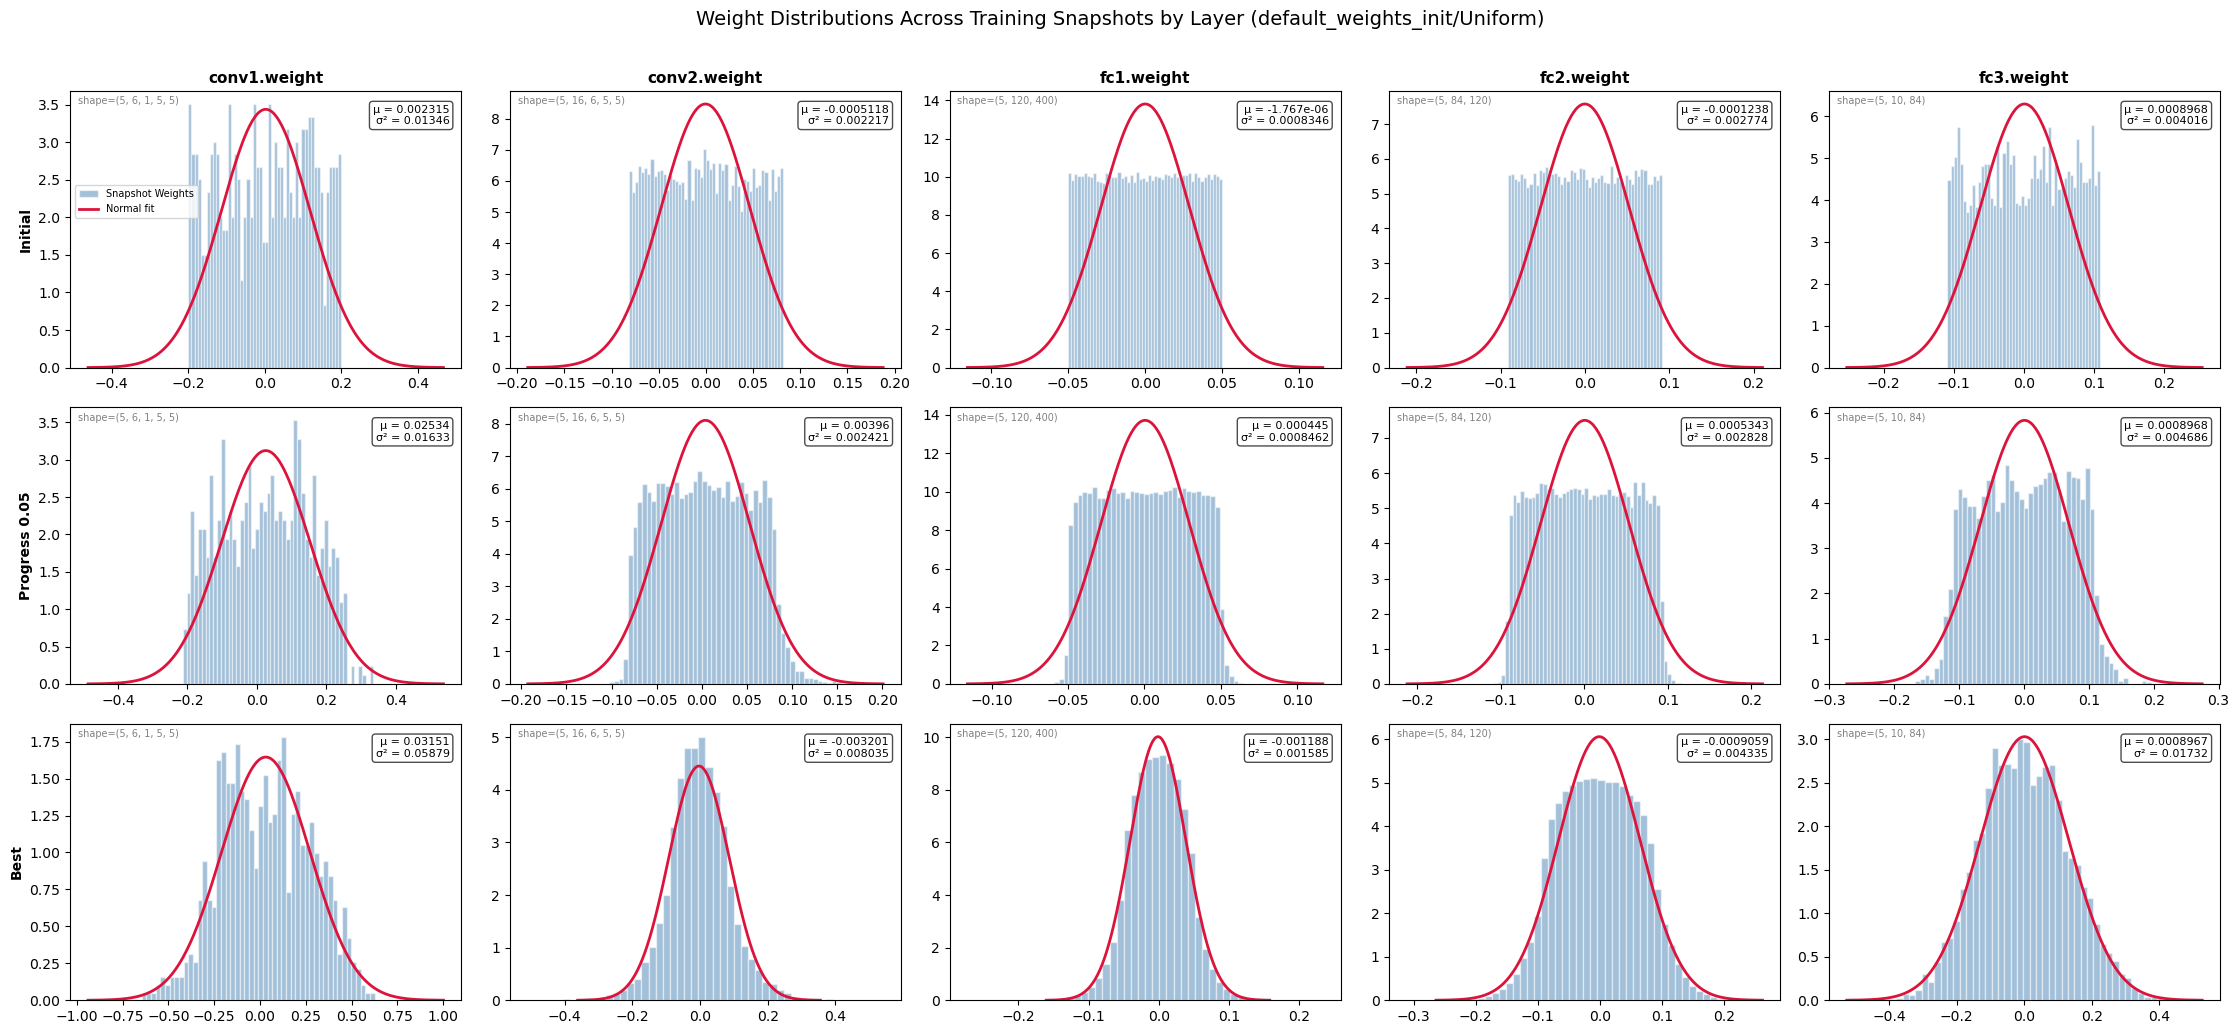

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

layer_keys = ['conv1.weight', 'conv2.weight', 'fc1.weight', 'fc2.weight', 'fc3.weight']
snapshots = [initial_snapshot, progress_start_snapshot, best_snapshot]
snapshot_labels = ['Initial', 'Progress 0.05', 'Best']

nrows, ncols = len(snapshots), len(layer_keys)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))

for row, (snapshot, label) in enumerate(zip(snapshots, snapshot_labels)):
    for col, key in enumerate(layer_keys):
        ax = axes[row, col]

        data_shape = snapshot[key].shape
        data = snapshot[key].numpy().flatten()

        mean = np.mean(data)
        variance = np.var(data)
        std = np.sqrt(variance)

        # histogram (density=True so it's on the same scale as the pdf)
        bins = min(50, max(10, len(data) // 3))
        ax.hist(data, bins=bins, density=True, alpha=0.5, color='steelblue',
                edgecolor='white', label='Snapshot Weights')

        # overlaid fitted normal curve
        x = np.linspace(mean - 4*std, mean + 4*std, 300)
        pdf = norm.pdf(x, loc=mean, scale=std)
        ax.plot(x, pdf, color='crimson', lw=2, label='Normal fit')

        # row label only on leftmost column, column label only on top row
        if col == 0:
            ax.set_ylabel(label, fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(key, fontsize=11, fontweight='bold')

        ax.text(0.02, 0.98, f"shape={tuple(data_shape)}", transform=ax.transAxes,
                ha='left', va='top', fontsize=7, color='gray')

        stats_str = f"μ = {mean:.4g}\nσ² = {variance:.4g}"
        ax.text(0.97, 0.95, stats_str, transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(0.0, 0.6))

fig.suptitle(f"Weight Distributions Across Training Snapshots by Layer ({init_type}/{model})", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()